# Anaysis of the behaviour of both the signaller and the reciever

In [17]:
import matplotlib.pyplot as plt
import os

plot_counter = 0

OUTPUT_DIR = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1"

plot_counter = 0

def save_current_figure():
    global plot_counter
    fig = plt.gcf()  # Get current figure
    filename = os.path.join(OUTPUT_DIR, f"plot_{plot_counter}.png")
    fig.savefig(filename, bbox_inches="tight", dpi=300)
    print("Saved:", filename)
    plot_counter += 1
    plt.close(fig)

Imports

In [18]:
# Imports

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# load in the results
result_dir = "/Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/"

date = "2026-02-27/"
slurm_job = 15939302

result_dir = result_dir + date + str(slurm_job) + "/"
# result_dir = result_dir + date + "v/"

The behaver files are formatted in the following way
- grouped into lines of threes
- first three are three different positions where the first landmark has the food
- second three -> the second landmark has the food
- third three -> the third landmark has the food
- each line the landmark is in a new place
- each line contains the behaviour across all three of the stages

## Helper functions

In [19]:
def read_every_ith_line(i, filename):
    
    with open(filename, "r") as file:
        rows = file.readlines()
    
    return [row.strip().split() for row in rows[::i]]

In [20]:

# Read first line function
def read_first_line(filename):
    # read the input file
    with open(filename, "r") as file:
        return file.readline().strip().split()

In [21]:
def read_ith_line(i, filename):
    with open(filename, "r") as file:
        for line_number, line in enumerate(file, start=1):
            if (line_number == i):
                return [float(x) for x in line.strip().split()]
            
    raise ValueError(f"File {filename} has fewer than {i} lines")

# Code for a single batch

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_47574/2593514501.py:57: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


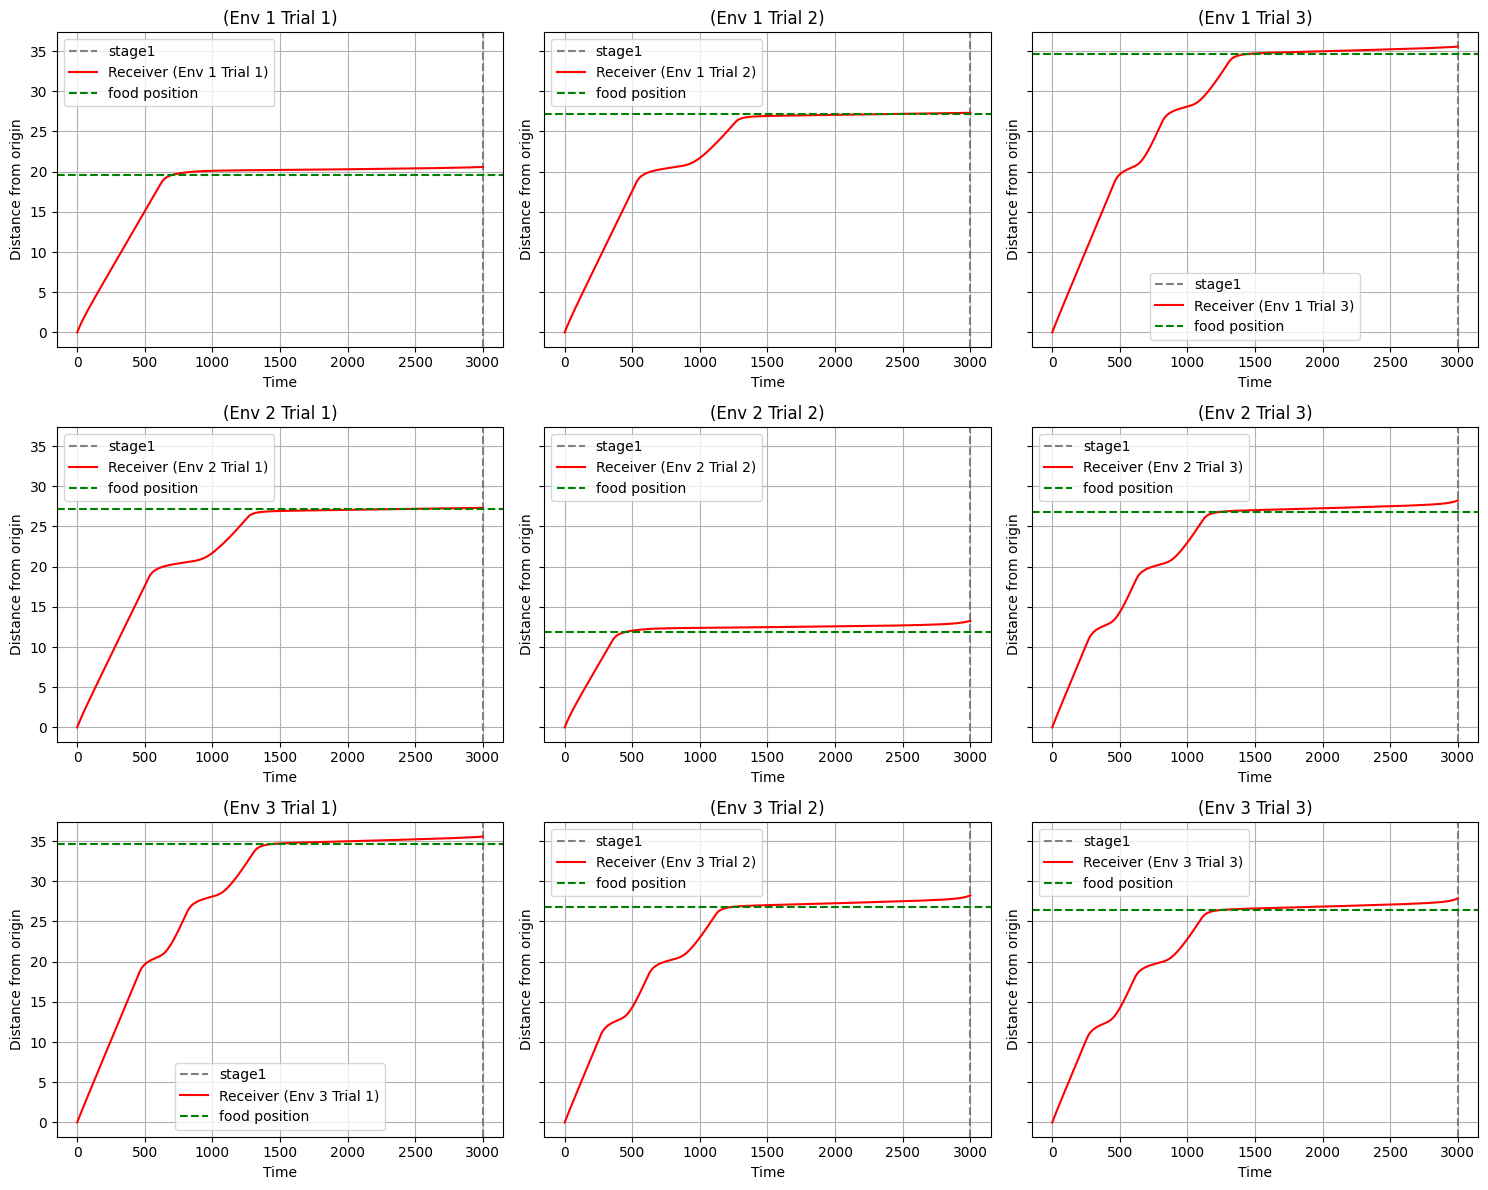

In [22]:
# this is looking at a single file

stages = ["stage1"]
envs = [1,2,3]
trials = [1,2,3]
batch = 0
run = 0

fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)

for env_index, env in enumerate(envs):
    
    for trial_index, trial in enumerate(trials):
        ax = axes[env_index, trial_index]
        # overall_evolution_dir_reciever = result_dir + "batch_"+str(1)+"/run_"+str(0)+"/behavior_Receiver_stage1_"+ str(0)
        # overall_evolution_dir_signaller = result_dir + "batch_"+str(1)+"/run_"+str(0)+"/behavior_signaller_stage1_"+ str(0)
                    
        combined_signaller = []
        combined_receiver = []
        for stage in stages:
            overall_evolution_dir_reciever = result_dir + f"batch_{batch}/run_{run}/behavior_Receiver_{stage}_{run}.dat"
            # overall_evolution_dir_signaller = result_dir + f"batch_{batch}/run_{run}/behavior_Signaller_{stage}_{run}.dat"
            
            receiver = read_ith_line(trial*env, overall_evolution_dir_reciever)
            # receiver = read_ith_line(trial*env, overall_evolution_dir_signaller)

            # draw a line marking the end of the trail
            # plot the line marking the landmark position
            ax.axvline(x=len(receiver), linestyle="--", label=f"{stage}", color="grey")

            # combined_signaller.extend(signaller)
            combined_receiver.extend(receiver)

        landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_{stage}_{run}.dat"
        landmark = read_ith_line(trial*env, landmark_file)


        x = list(range(0, len(combined_receiver)))

        # plot the signaller and receiver
        ax.plot(x, combined_receiver, label=f"Receiver (Env {env} Trial {trial})", color="red")
        # ax.plot(x, combined_signaller, label=f"Signaller (Env {env} Trial {trial})", color="blue")

        # plot the line marking the landmark position
        ax.axhline(y=landmark[3], linestyle="--", label="food position", color="green")

        ax.set_xlabel("Time")
        ax.set_ylabel("Distance from origin")
    
        # plt.yticks([-5,-3,-1,0,1,3,5,7,9,11,13,15])
        ax.set_title(f"(Env {env} Trial {trial})")
        ax.grid(True)
        ax.legend()


fig.tight_layout()
fig.show()

# code for all batches

In [ ]:
# this is looking at a single file

stages = ["stage1"]
# stages = ["stage1"]
envs = [1,2,3]
trials = [1,2,3]
# envs = [3]
# trials = [3]

run = 0

batches = [0,1,2,3,4,5,8,11,12,13,14,15,16,17,18,19]
# batches = [0,1,2,3,4,5,8,11,12,13,14]
for batch_index, batch in enumerate(batches):
    fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)
    for env_index, env in enumerate(envs):
        
        for trial_index, trial in enumerate(trials):

            ax = axes[env_index, trial_index]

            # fig, ax = plt.subplots(figsize=(16,10))
            ax2 = ax.twinx()
            ax3 = ax.twinx()          # Third y-axis

            # Move third axis further right
            ax3.spines["right"].set_position(("outward", 60))

            # Prevent frame overlap
            ax3.set_frame_on(True)
            ax3.patch.set_visible(False)
  
            combined_signaller = []
            combined_receiver = []

            fitness_combined = []

            
            offset = 0

            for stage in stages:
                overall_evolution_dir_reciever = result_dir + f"batch_{batch}/run_{run}/behavior_Receiver_{stage}_{run}.dat"
                # overall_evolution_dir_signaller = result_dir + f"batch_{batch}/run_{run}/behavior_Signaler_{stage}_{run}.dat"
                fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{stage}_{run}.dat"
                
                receiver = read_ith_line(trial*env, overall_evolution_dir_reciever)
                # signaller = read_ith_line(trial*env, overall_evolution_dir_signaller)
                fitness = read_ith_line(trial*env, fitness_file)

                ax.axvline(offset, linestyle="--", label=f"{stage}", color="grey")

                stage_length = len(receiver)
                fitness_length = len(fitness)

                fitness_start = offset + (stage_length - fitness_length)
                fitness_end = offset + stage_length
                fitness_x = range(fitness_start, fitness_end)

                ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")
                

                # combined_signaller.extend(signaller)
                combined_receiver.extend(receiver)

                offset += stage_length


            # distance between the signaler  and receiver
            # distance = np.abs(np.array(combined_receiver) - np.array(combined_signaller))

            x = list(range(0, len(combined_receiver)))

            # plot the signaller and receiver
            ax.plot(x, combined_receiver, label=f"Receiver (Env {env} Trial {trial})", color="red")
            # ax.plot(x, combined_signaller, label=f"Signaller (Env {env} Trial {trial})", color="blue")
            # ax.plot(x, distance, label="Distance", linestyle=":", color="black")

            landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_stage1_{run}.dat"
            landmark = read_ith_line(trial*env, landmark_file)

            # plot the line marking the landmark position

            food = landmark[3]

            landmarks = [0,1,2]
            for i in landmarks:
                if (landmark[i] != food):
                    ax.axhline(y=landmark[i], linestyle="--", label="food position", color="grey")


            ax.axhline(y=food, linestyle="--", label="food position", color="green")



            # get the neural states
            neural_state_1_file = result_dir+ f"batch_{batch}/run_{run}/neuron1_stage1_0.dat"
            neural_state_2_file = result_dir+ f"batch_{batch}/run_{run}/neuron2_stage1_0.dat"
            neural_state_3_file = result_dir+ f"batch_{batch}/run_{run}/neuron3_stage1_0.dat"
            
            neuron1 = read_ith_line(trial*env, neural_state_1_file)
            neuron2 = read_ith_line(trial*env, neural_state_2_file)
            neuron3 = read_ith_line(trial*env, neural_state_3_file)

            motor = []

            for p in range(len(neuron1)):
                motor.append(neuron2[p]-neuron1[p])


            ax.set_xlabel("Time")
            ax.set_ylabel("Distance from origin")
            ax.set_ylim(bottom=-5, top=50)
            ax2.set_ylim(bottom=0, top=1)
            ax2.set_ylabel("Fitness")

            ax3.set_ylabel("Neuron Values")

            ax.set_title(f"(Batch {batch} Env {env} Trial {trial})")
            ax.grid(True)
            
            fig.tight_layout()
            fig.legend()
            fig.show()
    save_current_figure()

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_47574/2813131436.py:123: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_0.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_1.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_2.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_3.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_4.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_5.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_6.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/

## Neural States

In [ ]:
# this is looking at a neural states

stages = ["stage1"]
# stages = ["stage1"]
envs = [1,2,3]
trials = [1,2,3]
# envs = [3]
# trials = [3]

run = 0

batches = [0,1,2,3,4,5,8,11,12,13,14,15,16,17,18,19]
# batches = [0,1,2,3,4,5,8,11,12,13,14]


for batch_index, batch in enumerate(batches):
    # fig, axes = plt.subplots(3, 3, figsize=(15,12), sharey=True)
    for env_index, env in enumerate(envs):
        
        for trial_index, trial in enumerate(trials):

            # ax = axes[env_index, trial_index]

            fig, ax = plt.subplots(figsize=(16,10))
            ax2 = ax.twinx()
            ax3 = ax.twinx()          # Third y-axis

            # Move third axis further right
            ax3.spines["right"].set_position(("outward", 60))

            # Prevent frame overlap
            ax3.set_frame_on(True)
            ax3.patch.set_visible(False)
  
            combined_signaller = []
            combined_receiver = []

            fitness_combined = []

            
            offset = 0

            for stage in stages:
                overall_evolution_dir_reciever = result_dir + f"batch_{batch}/run_{run}/behavior_Receiver_{stage}_{run}.dat"
                # overall_evolution_dir_signaller = result_dir + f"batch_{batch}/run_{run}/behavior_Signaler_{stage}_{run}.dat"
                fitness_file = result_dir+ f"batch_{batch}/run_{run}/fitness_{stage}_{run}.dat"
                
                receiver = read_ith_line(trial*env, overall_evolution_dir_reciever)
                # signaller = read_ith_line(trial*env, overall_evolution_dir_signaller)
                fitness = read_ith_line(trial*env, fitness_file)

                ax.axvline(offset, linestyle="--", label=f"{stage}", color="grey")

                stage_length = len(receiver)
                fitness_length = len(fitness)

                fitness_start = offset + (stage_length - fitness_length)
                fitness_end = offset + stage_length
                fitness_x = range(fitness_start, fitness_end)

                ax2.plot(fitness_x, fitness, linestyle="dashdot", color="purple")
                

                # combined_signaller.extend(signaller)
                combined_receiver.extend(receiver)

                offset += stage_length


            # distance between the signaler  and receiver
            # distance = np.abs(np.array(combined_receiver) - np.array(combined_signaller))

            x = list(range(0, len(combined_receiver)))

            # plot the signaller and receiver
            ax.plot(x, combined_receiver, label=f"Receiver (Env {env} Trial {trial})", color="red")
            # ax.plot(x, combined_signaller, label=f"Signaller (Env {env} Trial {trial})", color="blue")
            # ax.plot(x, distance, label="Distance", linestyle=":", color="black")

            landmark_file = result_dir+ f"batch_{batch}/run_{run}/landmark_location_stage1_{run}.dat"
            landmark = read_ith_line(trial*env, landmark_file)

            # plot the line marking the landmark position

            food = landmark[3]

            landmarks = [0,1,2]
            for i in landmarks:
                if (landmark[i] != food):
                    ax.axhline(y=landmark[i], linestyle="--", label="food position", color="grey")


            ax.axhline(y=food, linestyle="--", label="food position", color="green")



            # get the neural states
            neural_state_1_file = result_dir+ f"batch_{batch}/run_{run}/neuron1_stage1_0.dat"
            neural_state_2_file = result_dir+ f"batch_{batch}/run_{run}/neuron2_stage1_0.dat"
            neural_state_3_file = result_dir+ f"batch_{batch}/run_{run}/neuron3_stage1_0.dat"
            
            neuron1 = read_ith_line(trial*env, neural_state_1_file)
            neuron2 = read_ith_line(trial*env, neural_state_2_file)
            neuron3 = read_ith_line(trial*env, neural_state_3_file)

            motor = []

            for p in range(len(neuron1)):
                motor.append(neuron2[p]-neuron1[p])

            ax3.plot(x, ([0] + neuron1), label=f"Neuron 1 - Inhibitor Motor", color="hotpink")
            ax3.plot(x, ([0] + neuron2), label=f"Neuron 2 - Excitor motor", color="deeppink")
            ax3.plot(x, ([0] + neuron3), label=f"Neuron 3", color="pink")
            ax3.plot(x, ([0] + motor), label=f"Motor Signal", color="fuchsia")

            ax.set_xlabel("Time")
            ax.set_ylabel("Distance from origin")
            ax.set_ylim(bottom=-5, top=50)
            ax2.set_ylim(bottom=0, top=1)
            ax2.set_ylabel("Fitness")

            ax3.set_ylabel("Neuron Values")

            ax.set_title(f"(Batch {batch} Env {env} Trial {trial})")
            ax.grid(True)
            


            fig.tight_layout()
            fig.legend()
            fig.show()
            save_current_figure()

/var/folders/fz/htwq5qzj5_d0ry3b14hmlrsw0000gn/T/ipykernel_47574/2062676811.py:131: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_11.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_12.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_13.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_14.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_15.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_16.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Dissertation/BeeCommunication/results/good_graphs/stage_1/plot_17.png
Saved: /Users/katiepambakian/Documents/BSc Computer Science/Y3/Disser